In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [4]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [5]:
for name, df in {
    "funds": funds,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
}.items():

    print("\n", name.upper())
    print(df.columns.tolist())


 FUNDS
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

 NAV
['amfi_code', 'date', 'nav']

 AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

 SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

 PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

 TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status'

In [6]:
nav['date'] = pd.to_datetime(nav['date'])

top10 = nav['amfi_code'].unique()[:10]

nav_top = nav[nav['amfi_code'].isin(top10)]

fig = px.line(
    nav_top,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trend of Top Funds'
)

fig.show()

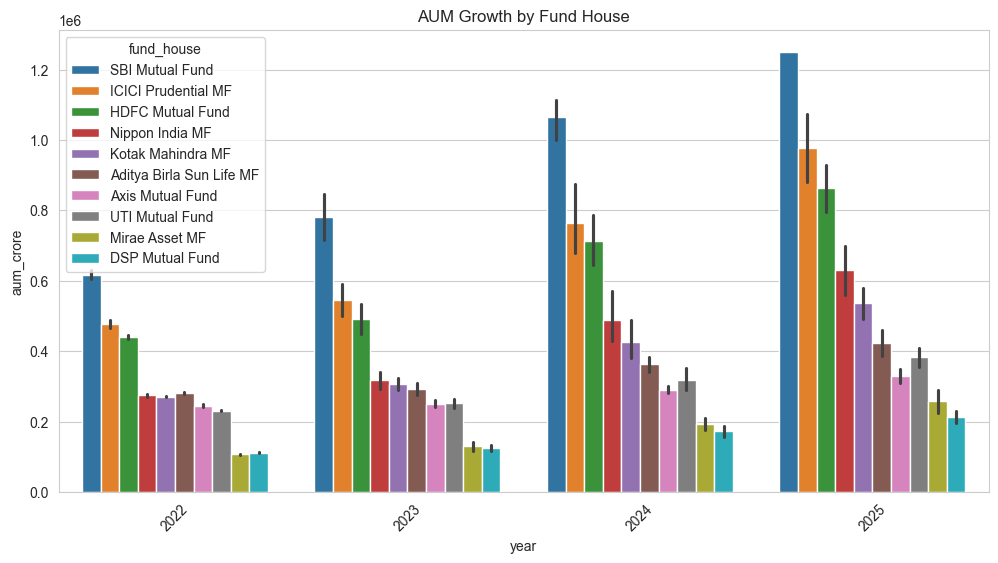

In [7]:
aum['year'] = pd.to_datetime(aum['date']).dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House')
plt.xticks(rotation=45)
plt.show()

In [8]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend'
)

fig.show()

In [9]:
fig = px.line(
    sip,
    x='month',
    y='sip_aum_lakh_crore',
    title='SIP AUM Trend'
)

fig.show()

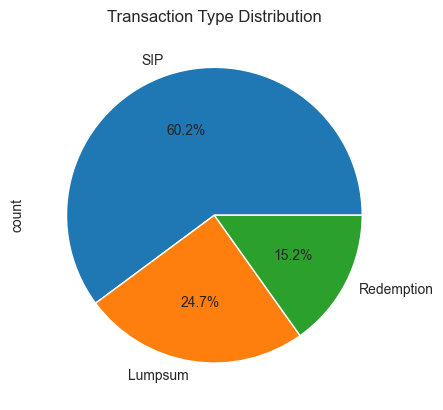

In [10]:
transactions['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Transaction Type Distribution')
plt.show()

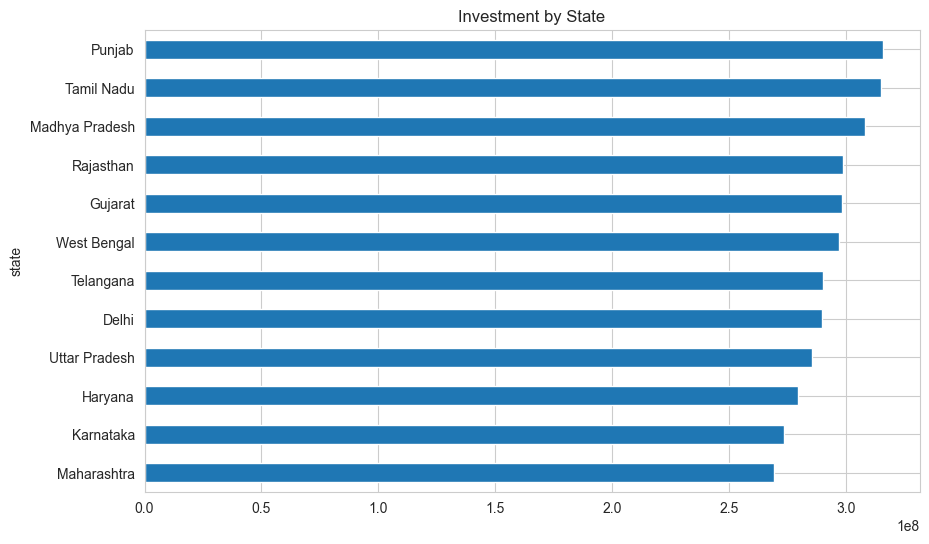

In [11]:
state_amt = transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values()

state_amt.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Investment by State')
plt.show()

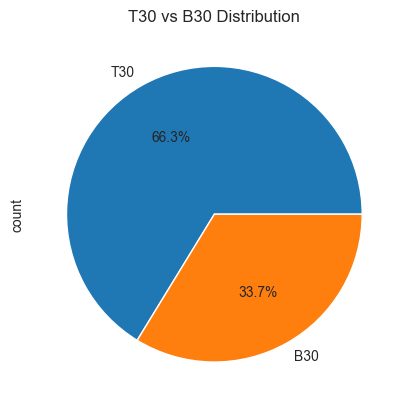

In [12]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Distribution')
plt.show()

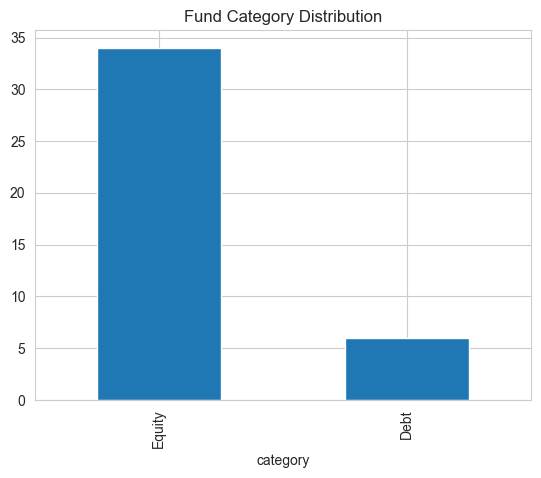

In [13]:
funds['category'].value_counts().plot(
    kind='bar'
)

plt.title('Fund Category Distribution')
plt.show()

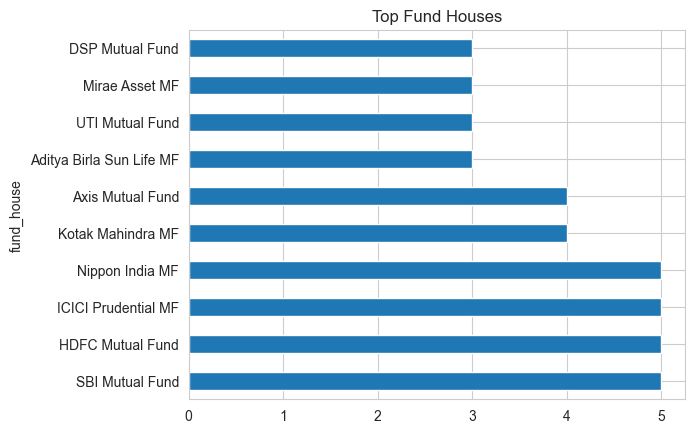

In [14]:
funds['fund_house'].value_counts().head(10).plot(
    kind='barh'
)

plt.title('Top Fund Houses')
plt.show()

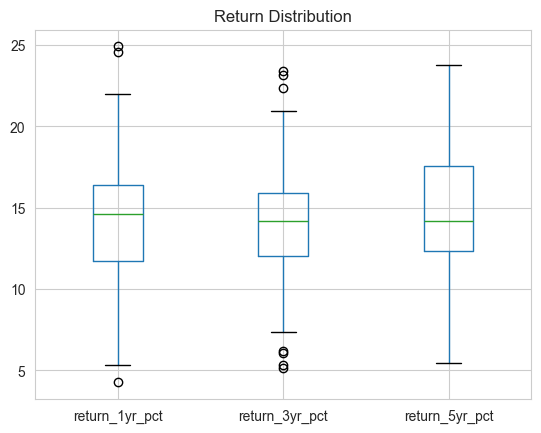

In [15]:
performance[['return_1yr_pct',
             'return_3yr_pct',
             'return_5yr_pct']].boxplot()

plt.title('Return Distribution')
plt.show()

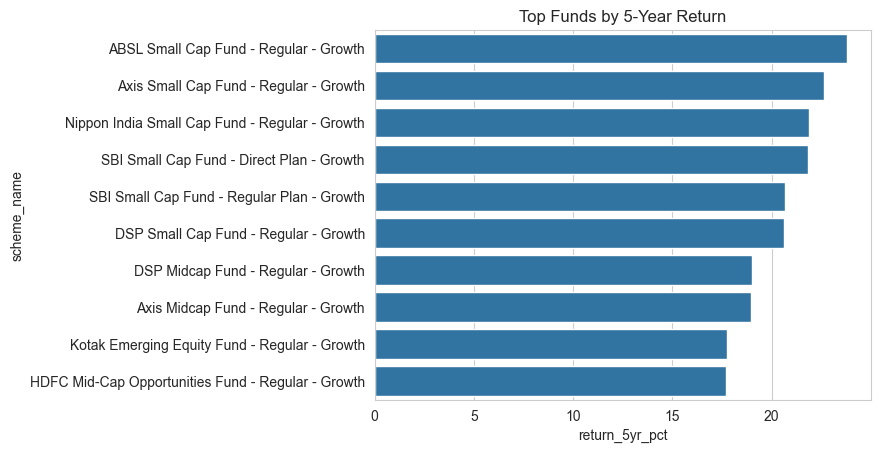

In [16]:
top = performance.sort_values(
    'return_5yr_pct',
    ascending=False
).head(10)

sns.barplot(
    data=top,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.title('Top Funds by 5-Year Return')
plt.show()

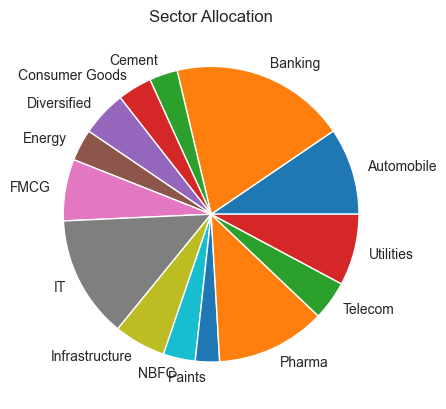

In [17]:
sector = holdings.groupby(
    'sector'
)['weight_pct'].sum()

plt.pie(
    sector,
    labels=sector.index
)

plt.title('Sector Allocation')
plt.show()

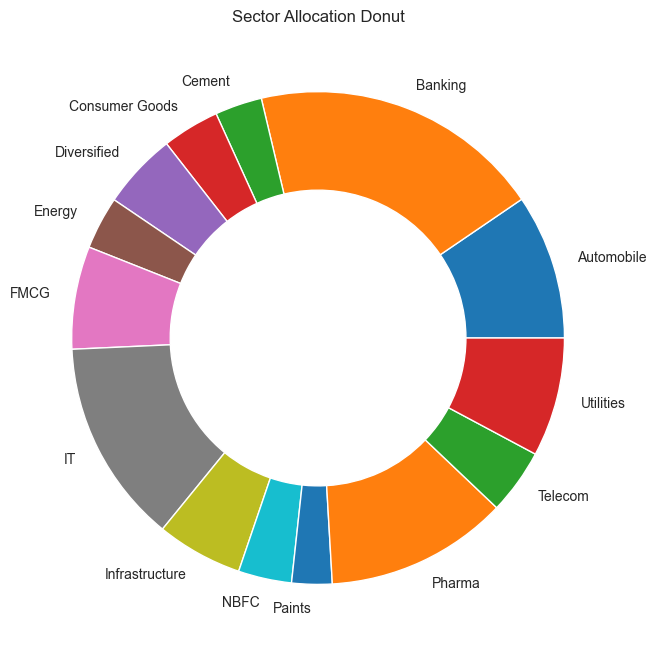

In [18]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={'width':0.4}
)

plt.title('Sector Allocation Donut')
plt.show()

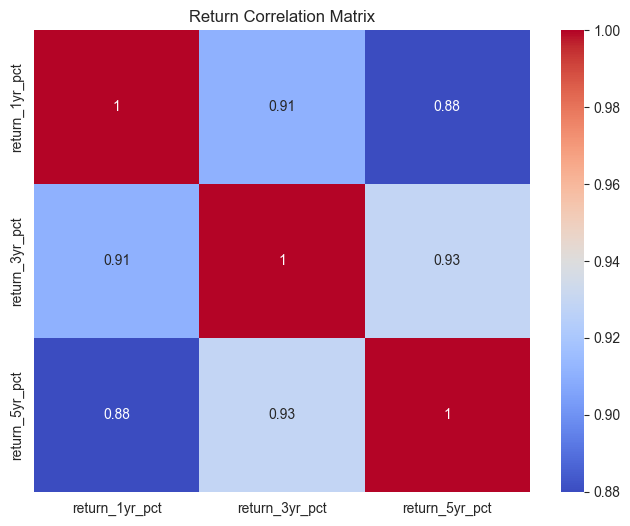

In [19]:
corr = performance[
    ['return_1yr_pct',
     'return_3yr_pct',
     'return_5yr_pct']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Return Correlation Matrix')
plt.show()

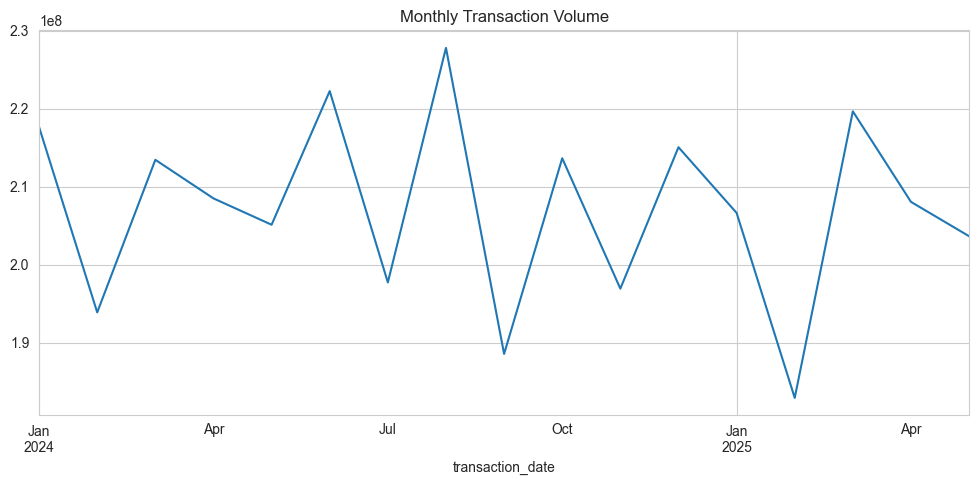

In [20]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

monthly = transactions.groupby(
    transactions['transaction_date'].dt.to_period('M')
)['amount_inr'].sum()

monthly.plot(figsize=(12,5))

plt.title('Monthly Transaction Volume')
plt.show()

# EDA Findings

## Insight 1

NAV values across most mutual fund schemes showed a long-term upward trend, indicating overall growth in fund performance.

## Insight 2

AUM increased significantly between 2022 and 2025, reflecting growing investor participation in mutual funds.

## Insight 3

SIP inflows demonstrated a consistent upward trend, highlighting increasing adoption of systematic investing.

## Insight 4

Large-cap and flexi-cap categories attracted the highest investment inflows among all fund categories.

## Insight 5

Transaction analysis revealed that SIP and lumpsum investments account for the majority of total transactions.

## Insight 6

Certain states contributed a significantly larger share of total investments compared to others.

## Insight 7

B30 cities contributed a meaningful share of investments, indicating increasing mutual fund penetration beyond major metropolitan areas.

## Insight 8

The correlation matrix showed strong positive relationships among several equity-oriented funds.

## Insight 9

Technology, Financial Services, and Banking sectors represented a substantial portion of portfolio allocations.

## Insight 10

Funds with higher long-term returns generally exhibited higher volatility, demonstrating the risk-return tradeoff in mutual fund investing.


# Conclusion

The exploratory data analysis provided insights into mutual fund performance, investor behavior, fund categories, and investment trends.

Key observations include:
- Consistent growth in AUM and SIP inflows.
- Strong long-term NAV growth across multiple schemes.
- Significant contributions from large-cap and flexi-cap categories.
- Growing participation from B30 cities and diverse investor groups.
- Positive correlation among several equity-oriented funds.

The EDA findings form the foundation for performance analytics, advanced analytics, and dashboard development.